In [1]:
import cooler
import cooltools
import bioframe as bf
import bbi
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ggner_3d.cm import CLR_CONNS, get_expected_cis_df, prepare_view_df
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score
from ggner_3d.dots_common import compare_loops_with_strength
from ggner_3d.bbi_helpers import stackup_bw_dict, stackup_bw_dict_q
from ggner_3d import plotting
from ggner_3d.plotting import plot_flanks_start_end_stackup, lineplot_stackup_dict
plotting.update_rcparams()

NPROC = 6
resolution = 10000
window = 500_000
clr_ = CLR_CONNS(resolution)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
xpc_peaks = '/home/carlos/Clone/xpc_ctcf_peaks/XPC_all.narrowPeak'
ctcf_peaks = '/home/carlos/Clone/xpc_ctcf_peaks/CTCF_all.narrowPeak'

xpc_peaks_df = pd.read_csv(xpc_peaks, sep='\t', header=None)[[0, 1, 2,9]].rename(columns={0: 'chrom', 1: 'start', 2: 'end', 9: 'peak'})
ctcf_peaks_df = pd.read_csv(ctcf_peaks, sep='\t', header=None)[[0, 1, 2,9]].rename(columns={0: 'chrom', 1: 'start', 2: 'end', 9: 'peak'})

overlap = bf.overlap(xpc_peaks_df, ctcf_peaks_df).dropna(subset=['start_'])
overlap['xpc_summit'] = overlap['start'] + overlap['peak'] - 1
overlap['ctcf_summit'] = overlap['start_'] + overlap['peak_'] - 1
overlap['center_point'] = (overlap['xpc_summit'] + overlap['ctcf_summit']) // 2



def filterfor_canonical_chromosomes(df):
    canonical_chroms = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']
    return df[df['chrom'].isin(canonical_chroms)]

flank = 20_000
overlap['flank_start'] = overlap['center_point'] - flank
overlap['flank_end'] = overlap['center_point'] + flank

non_overlap_xpc = bf.subtract(xpc_peaks_df, ctcf_peaks_df)
non_overlap_xpc['flank_start'] = non_overlap_xpc['start'] + non_overlap_xpc['peak'] - 1 - flank
non_overlap_xpc['flank_end'] = non_overlap_xpc['start'] + non_overlap_xpc['peak'] - 1 + flank

non_overlap_ctcf = bf.subtract(ctcf_peaks_df, xpc_peaks_df)
non_overlap_ctcf['flank_start'] = non_overlap_ctcf['start'] + non_overlap_ctcf['peak'] - 1 - flank
non_overlap_ctcf['flank_end'] = non_overlap_ctcf['start'] + non_overlap_ctcf['peak'] - 1 + flank


overlap = filterfor_canonical_chromosomes(overlap)
non_overlap_xpc = filterfor_canonical_chromosomes(non_overlap_xpc)
non_overlap_ctcf = filterfor_canonical_chromosomes(non_overlap_ctcf)

In [3]:
pol2_wt_dict = {
    'wt_nouv_pol2': ["/home/carlos/Clone/ggner-3d/GSM7162996_NCRNAPolIIChIP.primary.ucsc.bw"]}

from ggner_3d.bbi_helpers import stackup_bw_dict

bins = 2000
stackup_overlap = stackup_bw_dict(pol2_wt_dict, overlap[['chrom', 'flank_start', 'flank_end']], bins)['wt_nouv_pol2']
stackup_non_overlap_xpc = stackup_bw_dict(pol2_wt_dict, non_overlap_xpc[['chrom', 'flank_start', 'flank_end']], bins)['wt_nouv_pol2']
stackup_non_overlap_ctcf = stackup_bw_dict(pol2_wt_dict, non_overlap_ctcf[['chrom', 'flank_start', 'flank_end']], bins)['wt_nouv_pol2']

/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:18: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}
/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:18: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}


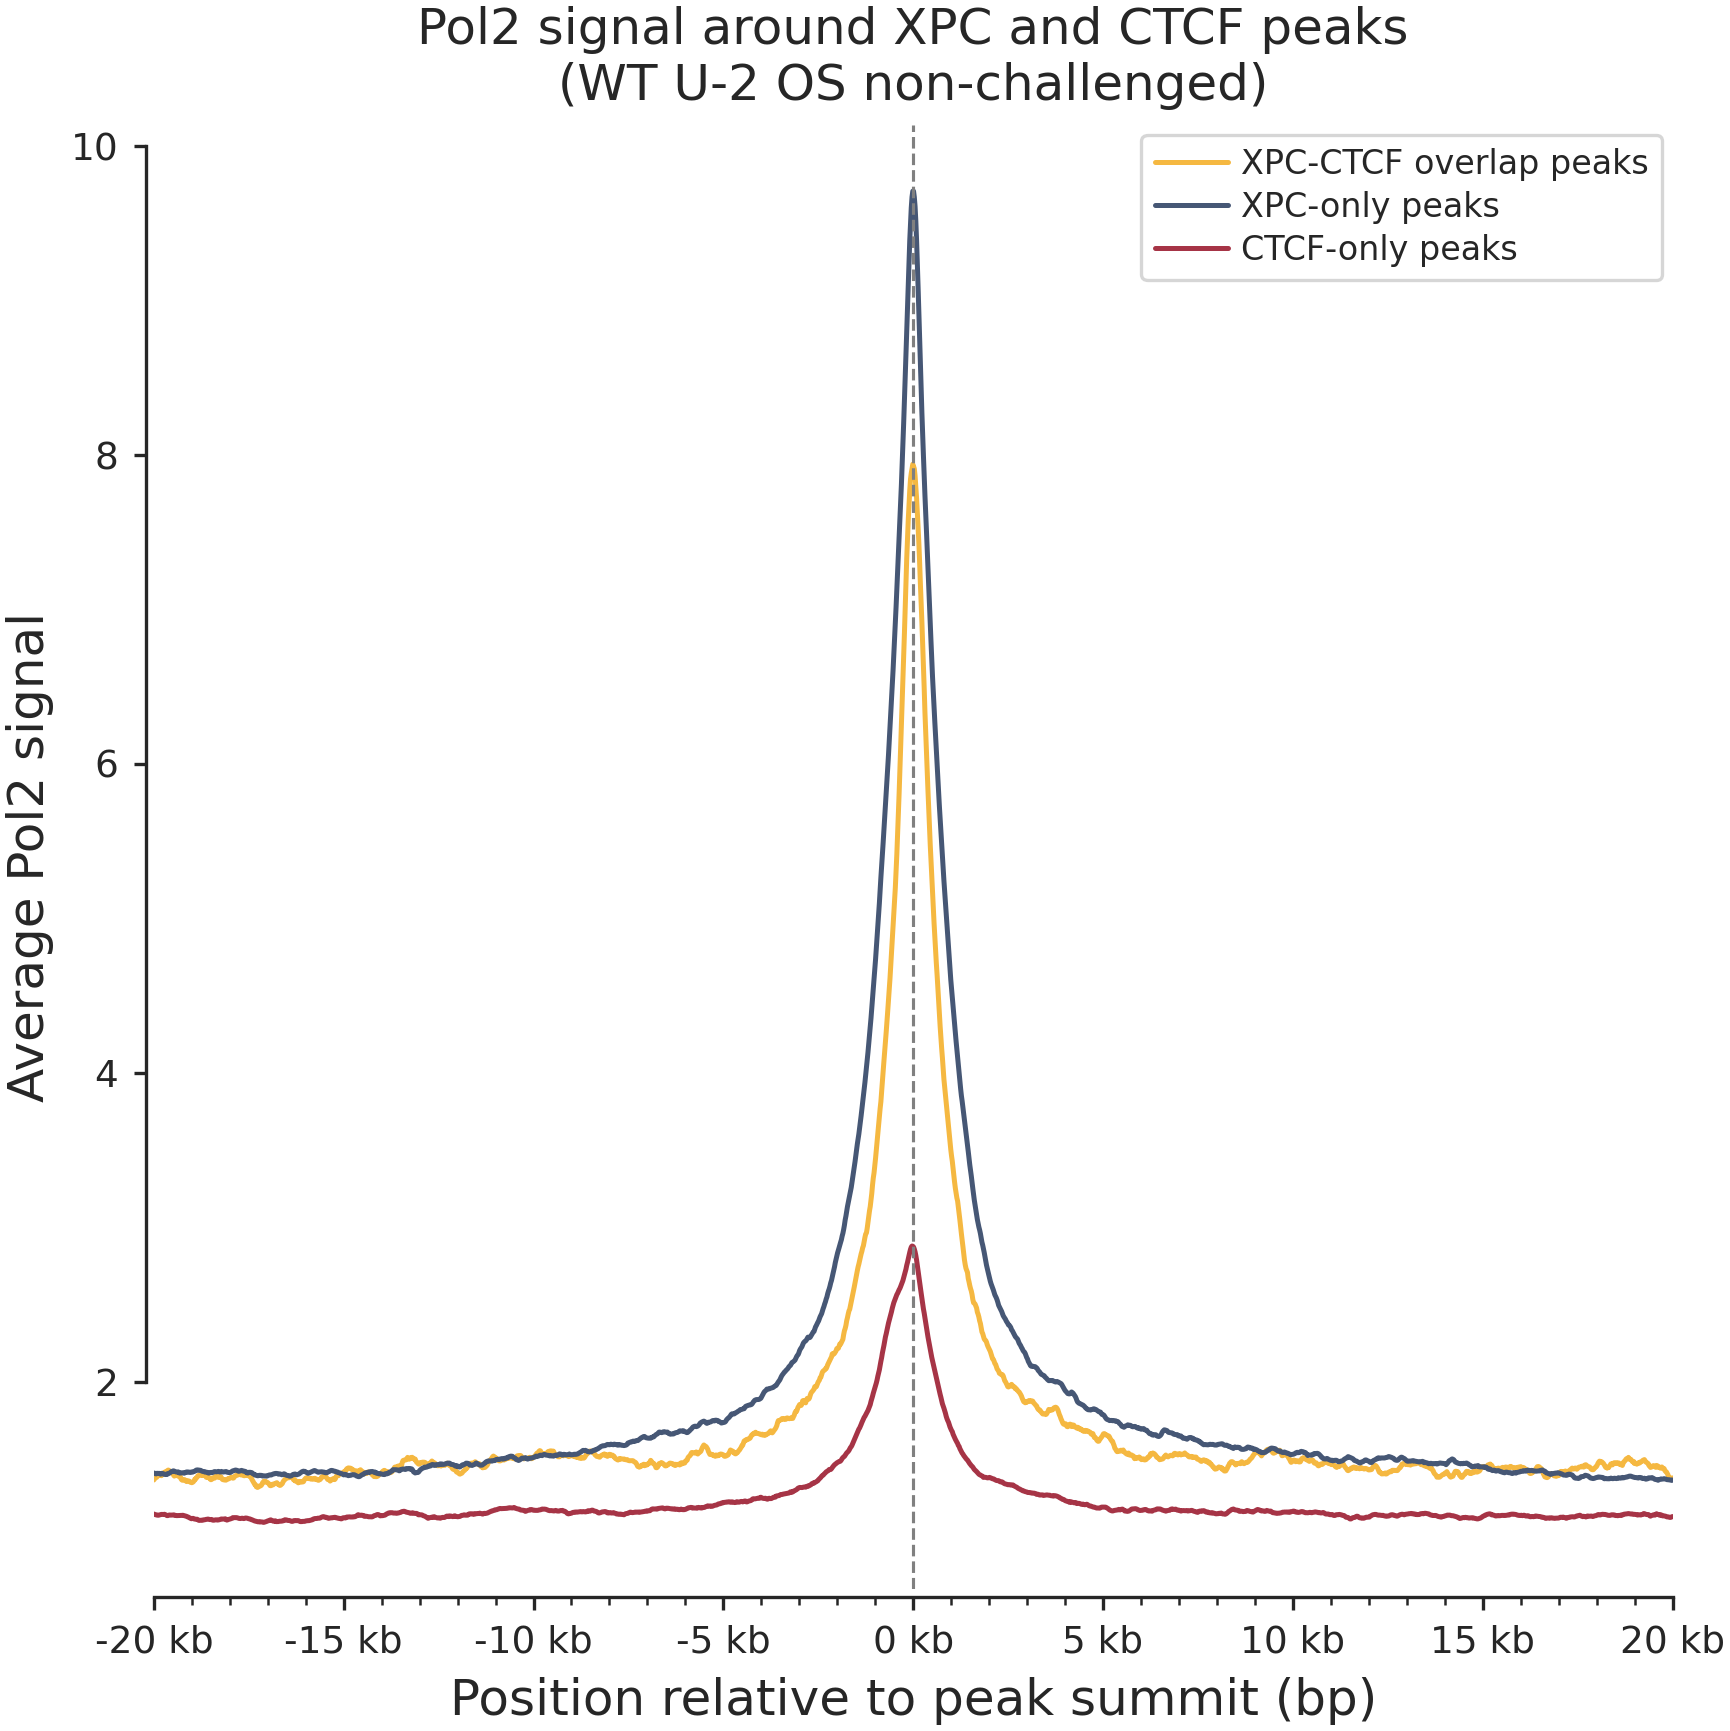

In [4]:
# -----------------------------
# Plot Pol2 signal around peaks
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Parameters
bins = stackup_overlap.shape[1]

# Genomic coordinate axis
x = np.linspace(-flank, flank, bins)

# Mean signal
mean_overlap = np.nanmean(stackup_overlap, axis=0)
mean_xpc_only = np.nanmean(stackup_non_overlap_xpc, axis=0)
mean_ctcf_only = np.nanmean(stackup_non_overlap_ctcf, axis=0)

# Plot
plotting.update_rcparams()
fig, ax = plt.subplots(figsize=(6, 6))
colors = plotting.COLORS

sns.lineplot(x=x, y=mean_overlap,
             color=colors[2], label='XPC-CTCF overlap peaks', ax=ax)

sns.lineplot(x=x, y=mean_xpc_only,
             color=colors[0], label='XPC-only peaks', ax=ax)

sns.lineplot(x=x, y=mean_ctcf_only,
             color=colors[1], label='CTCF-only peaks', ax=ax)

# Formatting
ax.set_title("Pol2 signal around XPC and CTCF peaks\n(WT U-2 OS non-challenged)")
ax.set_xlabel("Position relative to peak summit (bp)")
ax.set_ylabel("Average Pol2 signal")

# Vertical line at summit
ax.axvline(0, linestyle='--', linewidth=0.75, color='grey')

# Major ticks every 5 kb
ax.xaxis.set_major_locator(mticker.MultipleLocator(5000))
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{int(x/1000)} kb")
)

# Minor ticks every 1 kb
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1000))

# Limits
ax.set_xlim(-flank, flank)

plotting.despine(ax)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
tss = pd.read_csv('/home/carlos/Clone/ggner-3d/tss.bed', sep='\t', header=None)
tss.columns = ['chrom', 'start', 'end', 'gene', 'score', 'strand']

In [6]:
tss

,chrom,start,end,gene,score,strand
0,chr20,47992287,47992288,ENSG00000237423.4,.,-
1,chr20,24992781,24992782,ENSG00000101474.13,.,-
2,chr19,35586160,35586161,ENSG00000283758.2,.,+
3,chr17,51120925,51120926,ENSG00000008294.23,.,-
4,chr17,20323057,20323058,ENSG00000266839.3,.,+
...,...,...,...,...,...,...
78894,chr5,97057357,97057358,ENSG00000213701.4,.,-
78895,chr4,47652668,47652669,ENSG00000277388.1,.,+
78896,chr3,49160850,49160851,ENSG00000270441.1,.,-
78897,chr1,209001337,209001338,ENSG00000278684.1,.,+


In [7]:
import numpy as np
import pandas as pd

def promoter_density_2d(tss, coordinate_df, flank=100_000, n_bins=100):

    # Strand-aware TSS coordinate
    tss_coord = np.where(
        tss["strand"].values == "+",
        tss["start"].values,
        tss["end"].values
    )

    tss_df = pd.DataFrame({
        "chrom": tss["chrom"].values,
        "tss": tss_coord
    })

    # Midpoint of coordinate intervals
    coord_mid = (
        (coordinate_df["start"].values +
         coordinate_df["end"].values) // 2
    )

    coords_df = pd.DataFrame({
        "chrom": coordinate_df["chrom"].values,
        "mid": coord_mid
    })

    # Output matrix
    density = np.zeros((len(coords_df), n_bins), dtype=np.int32)

    bin_size = (2 * flank) / n_bins

    # Process per chromosome (vectorized inside chrom)
    for chrom in coords_df["chrom"].unique():

        coord_idx = np.where(coords_df["chrom"] == chrom)[0]
        tss_idx = np.where(tss_df["chrom"] == chrom)[0]

        if len(coord_idx) == 0 or len(tss_idx) == 0:
            continue

        coord_positions = coords_df["mid"].values[coord_idx]
        tss_positions = tss_df["tss"].values[tss_idx]

        # Compute distance matrix (broadcasted)
        dist = tss_positions[:, None] - coord_positions[None, :]

        # Keep only within flank
        mask = np.abs(dist) <= flank

        # Convert distances to bin indices
        bin_index = ((dist + flank) / bin_size).astype(int)

        # Clip edge case
        bin_index = np.clip(bin_index, 0, n_bins - 1)

        # Accumulate counts
        for tss_i in range(len(tss_positions)):
            valid_coords = np.where(mask[tss_i])[0]
            bins = bin_index[tss_i, valid_coords]
            np.add.at(density, (coord_idx[valid_coords], bins), 1)

    return density

In [11]:
import numpy as np
import pandas as pd


def make_genome_windows(chrom_sizes, window_size):
    """
    chrom_sizes: dict like {"chr1": 248956422, "chr2": 242193529, ...}
    window_size: int

    returns: DataFrame with columns [chrom, start, end]
    """
    rows = []
    for chrom, size in chrom_sizes.items():
        starts = np.arange(0, size, window_size, dtype=np.int64)
        ends = np.minimum(starts + window_size, size)
        rows.append(pd.DataFrame({
            "chrom": chrom,
            "start": starts,
            "end": ends
        }))
    return pd.concat(rows, ignore_index=True)


def promoter_density_per_window(tss_df, chrom_sizes, window_size, flank=100_000):
    """
    For each fixed genome window, compute promoter density around the window midpoint.

    tss_df must have columns: chrom, start, end, strand
    chrom_sizes: dict of chromosome lengths
    window_size: size of genome windows in bp
    flank: region around window midpoint to count TSS

    returns: DataFrame with columns [chrom, start, end, promoter_density, promoter_count]
    """

    # Strand-aware TSS coordinate
    tss_coord = np.where(
        tss_df["strand"].values == "+",
        tss_df["start"].values,
        tss_df["end"].values
    )

    tss = pd.DataFrame({
        "chrom": tss_df["chrom"].values,
        "tss": tss_coord
    })

    # Build equal windows across genome
    windows = make_genome_windows(chrom_sizes, window_size).copy()

    # Midpoint of each window
    windows["mid"] = ((windows["start"].values + windows["end"].values) // 2).astype(np.int64)

    promoter_counts = np.zeros(len(windows), dtype=np.int32)

    # Per chromosome: use searchsorted for efficiency
    for chrom in windows["chrom"].unique():
        w_idx = np.where(windows["chrom"].values == chrom)[0]
        t_idx = np.where(tss["chrom"].values == chrom)[0]

        if len(w_idx) == 0:
            continue
        if len(t_idx) == 0:
            promoter_counts[w_idx] = 0
            continue

        mids = windows["mid"].values[w_idx]
        tss_pos = np.sort(tss["tss"].values[t_idx])

        left_edges = mids - flank
        right_edges = mids + flank

        left_idx = np.searchsorted(tss_pos, left_edges, side="left")
        right_idx = np.searchsorted(tss_pos, right_edges, side="right")

        promoter_counts[w_idx] = right_idx - left_idx

    # Density = promoters per bp in the 2*flank neighborhood
    windows["promoter_count"] = promoter_counts
    windows["promoter_density"] = promoter_counts / (2 * flank)

    return windows[["chrom", "start", "end", "promoter_density", "promoter_count"]]

import bioframe as bf
chromsizes = bf.fetch_chromsizes('hg38')[:23]


promoter_density_full = promoter_density_per_window(
    tss,
    chrom_sizes=chromsizes,
    window_size=1000,
    flank=500
)

promoter_density_full = promoter_density_full.loc[promoter_density_full["promoter_count"] > 0].reset_index(drop=True).iloc[:, :4]
bf.to_bigwig(
    df=promoter_density_full,
    chromsizes=chromsizes,
    outpath='/home/carlos/Clone/ggner-3d/promoter_density_1kb_window_500bp_flank.bw',
    path_to_binary='/home/carlos/micromamba/envs/hic/bin/bedGraphToBigWig'
)

CompletedProcess(args=['/home/carlos/micromamba/envs/hic/bin/bedGraphToBigWig', '/tmp/tmpyo6ojnow.bg', '/tmp/tmpcn0bnwmk.chrom.sizes', '/home/carlos/Clone/ggner-3d/promoter_density_1kb_window_500bp_flank.bw'], returncode=0, stdout=b'', stderr=b'')

In [9]:
overlap_df = overlap[['chrom', 'flank_start', 'flank_end']].rename(columns={'flank_start': 'start', 'flank_end': 'end'})
overlap_df.start = overlap_df.start.astype(int)
overlap_df.end = overlap_df.end.astype(int)
overlap_density_matrix = promoter_density_2d(tss, overlap_df, flank=flank, n_bins=200)

xpc_only_df = non_overlap_xpc[['chrom', 'flank_start', 'flank_end']].rename(columns={'flank_start': 'start', 'flank_end': 'end'})
xpc_only_df.start = xpc_only_df.start.astype(int)
xpc_only_df.end = xpc_only_df.end.astype(int)
xpc_only_density_matrix = promoter_density_2d(tss, xpc_only_df, flank=flank, n_bins=200)

ctcf_only_df = non_overlap_ctcf[['chrom', 'flank_start', 'flank_end']].rename(columns={'flank_start': 'start', 'flank_end': 'end'})
ctcf_only_df.start = ctcf_only_df.start.astype(int)
ctcf_only_df.end = ctcf_only_df.end.astype(int)
ctcf_only_density_matrix = promoter_density_2d(tss, ctcf_only_df, flank=flank, n_bins=200)

<Axes: >

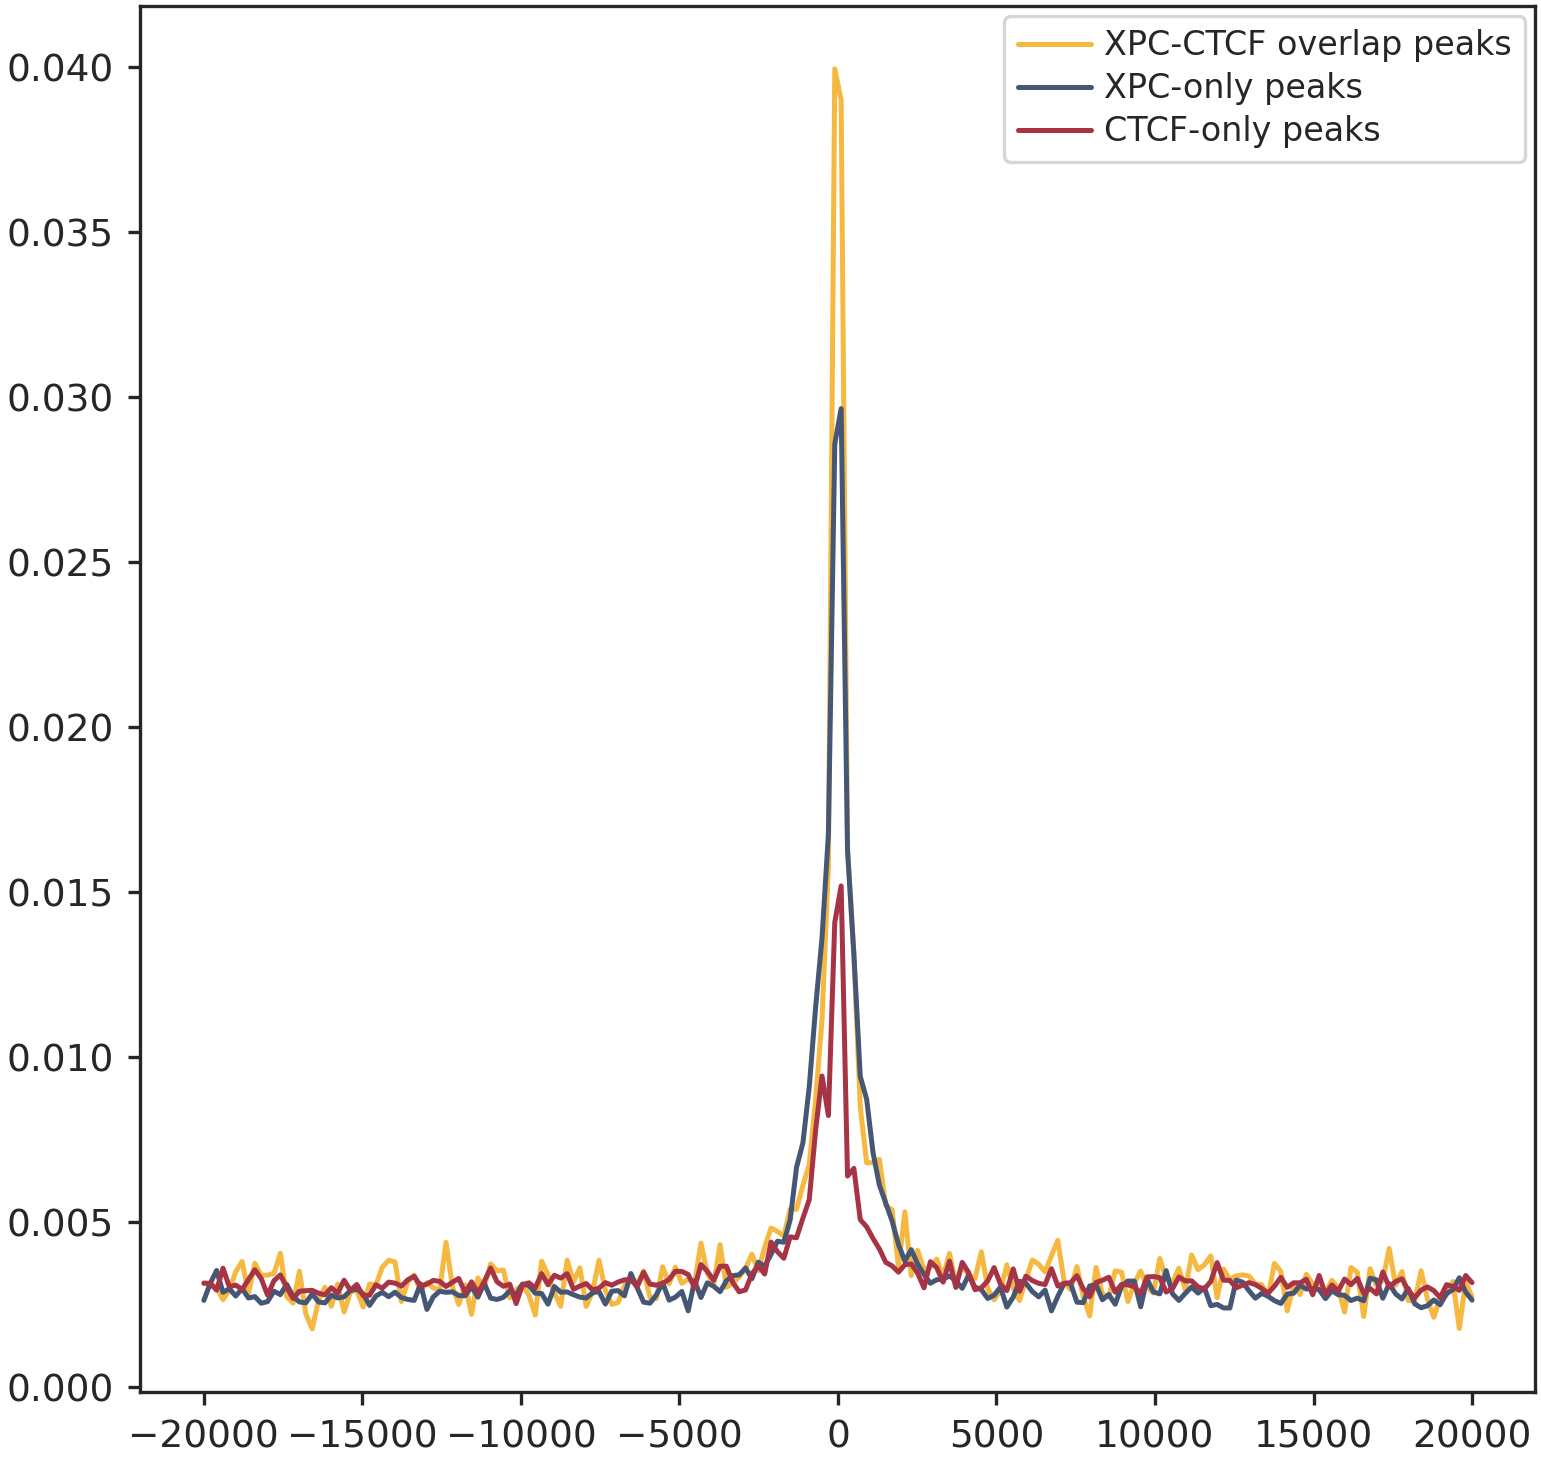

In [8]:
def rowwise_normalize(mat, eps=0.0, keep_zeros=True, dtype=None):
    mat = np.asarray(mat)
    if mat.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {mat.shape}")

    row_sums = mat.sum(axis=1)
    denom = row_sums[:, None].astype(np.float64, copy=False) + eps

    if keep_zeros:
        denom = np.where(row_sums[:, None] == 0, 1.0, denom)
        norm = mat / denom
    else:
        norm = mat / denom
        norm[row_sums == 0] = np.nan

    if dtype is not None:
        norm = norm.astype(dtype, copy=False)

    return norm, row_sums

plotting.update_rcparams()
fig, ax = plt.subplots(figsize=(6, 6))
colors = plotting.COLORS

x_now = np.linspace(-flank, flank, 200)

sns.lineplot(x=x_now, y=np.nanmean(rowwise_normalize(overlap_density_matrix)[0], axis=0),
             color=colors[2], label='XPC-CTCF overlap peaks', ax=ax)
sns.lineplot(x=x_now, y=np.nanmean(rowwise_normalize(xpc_only_density_matrix)[0], axis=0),
             color=colors[0], label='XPC-only peaks', ax=ax)
sns.lineplot(x=x_now, y=np.nanmean(rowwise_normalize(ctcf_only_density_matrix)[0], axis=0),
             color=colors[1], label='CTCF-only peaks', ax=ax)

In [9]:
def get_insulation_fixed(insul_df, coord_df, insul_column, flank=100_000, resolution=10_000):
    
    insul_df = insul_df.copy()
    coord_df = coord_df.copy()

    insul_df['mid'] = (insul_df['start'] + insul_df['end']) // 2
    coord_df['mid'] = (coord_df['start'] + coord_df['end']) // 2

    bins_each_side = flank // resolution
    window_size = 2 * bins_each_side + 1

    results = []

    for chrom in coord_df['chrom'].unique():
        insul_chrom = insul_df[insul_df['chrom'] == chrom].reset_index(drop=True)
        coord_chrom = coord_df[coord_df['chrom'] == chrom]

        if insul_chrom.empty or coord_chrom.empty:
            continue

        insul_mids = insul_chrom['mid'].values
        insul_scores = insul_chrom[insul_column].values

        for _, row in coord_chrom.iterrows():
            mid = row['mid']

            # find closest insulation bin index
            idx = np.searchsorted(insul_mids, mid)

            start = idx - bins_each_side
            end = idx + bins_each_side + 1

            if start < 0 or end > len(insul_scores):
                continue

            results.append(insul_scores[start:end])

    return np.array(results)

In [16]:
flank = 500_000
insul_column = 'log2_insulation_score_500000'

wt_nouv_insul_df = pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv')

overlap_df = overlap[['chrom_', 'start_', 'end_']].copy()
overlap_df.columns = ['chrom', 'start', 'end']
overlap_df.start = overlap_df.start.astype(int)
overlap_df.end = overlap_df.end.astype(int)
insul_overlap = get_insulation_fixed(wt_nouv_insul_df, overlap_df, insul_column, flank=flank)

non_overlap_xpc = bf.subtract(xpc_peaks_df, ctcf_peaks_df)
insul_xpc = get_insulation_fixed(wt_nouv_insul_df, non_overlap_xpc, insul_column, flank=flank)

non_overlap_ctcf = bf.subtract(ctcf_peaks_df, xpc_peaks_df)
insul_ctcf = get_insulation_fixed(wt_nouv_insul_df, non_overlap_ctcf, insul_column, flank=flank)

<Axes: >

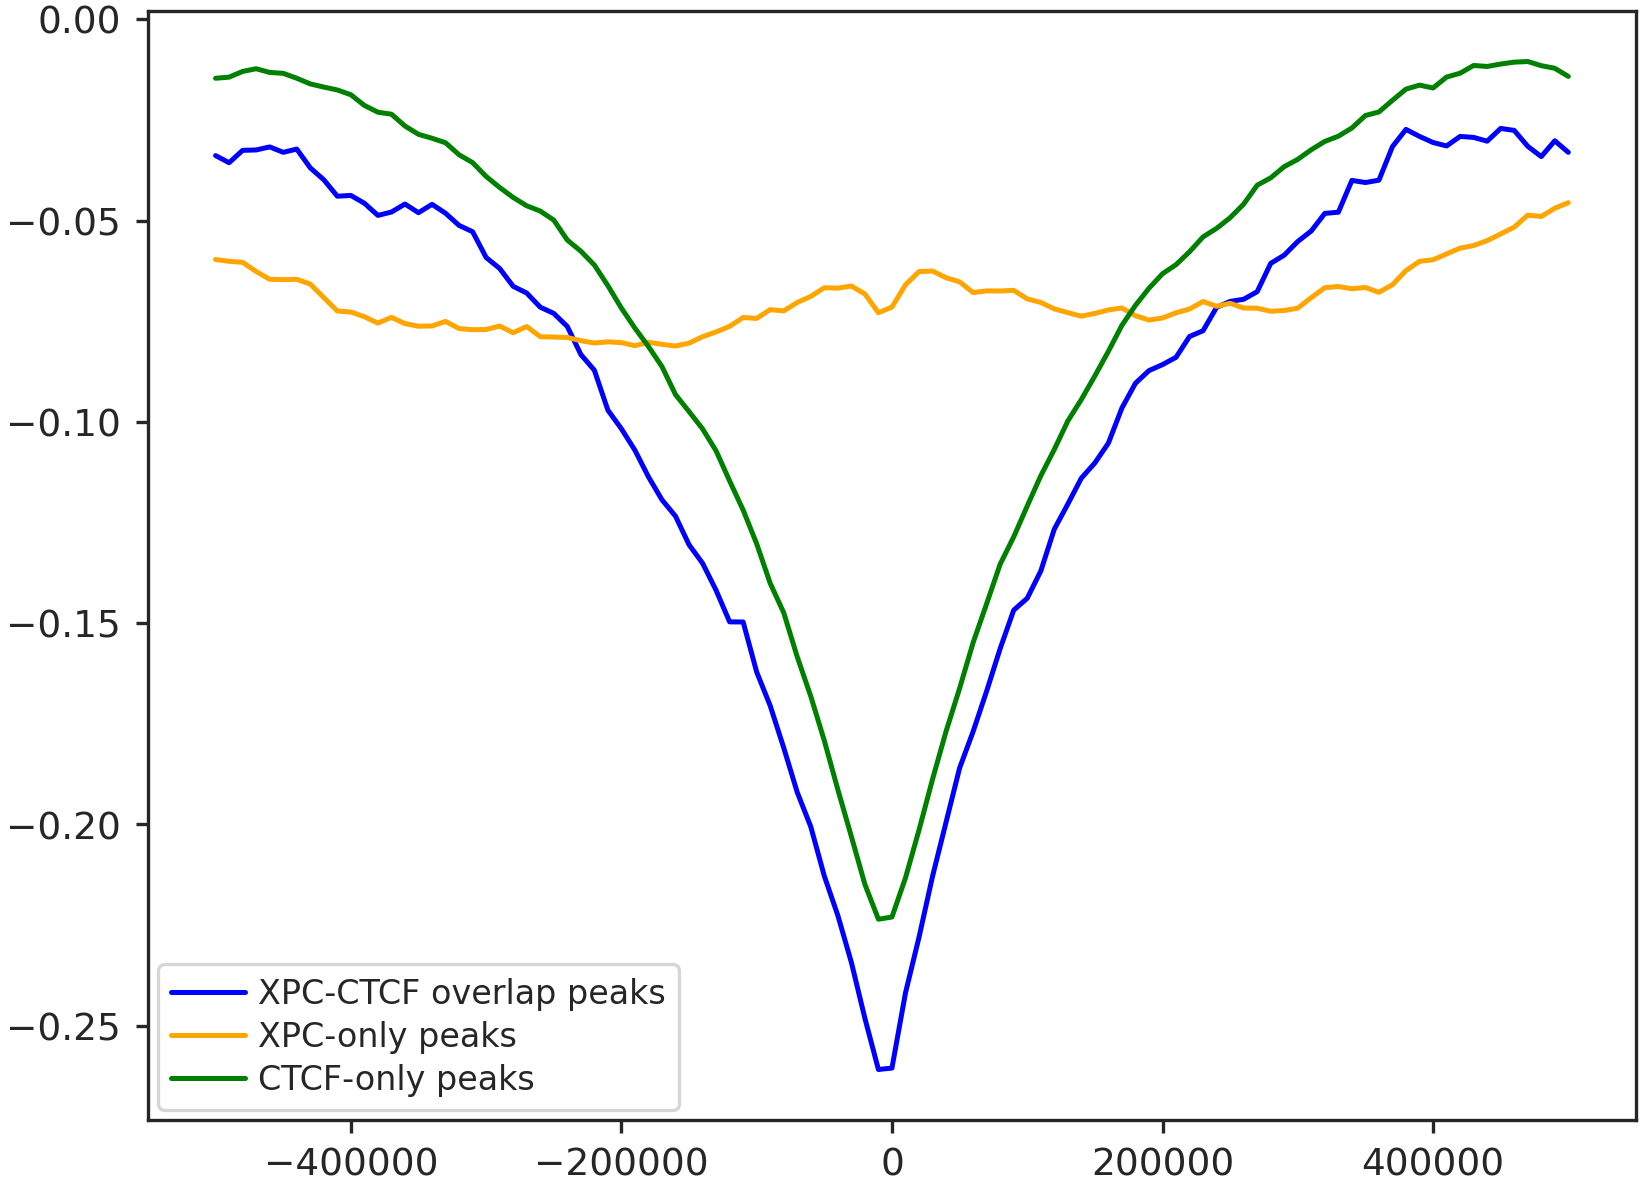

In [17]:
insul_overlap = [arr for arr in insul_overlap if len(arr) == flank * 2 // 10000 + 1]
insul_overlap_stack = np.array(insul_overlap)
data = np.nanmedian(insul_overlap_stack, axis=0)
sns.lineplot(x=np.linspace(-flank, flank, data.shape[0]), y=data, color='blue', label='XPC-CTCF overlap peaks'
)

insul_xpc = [arr for arr in insul_xpc if len(arr) == flank * 2 // 10000 + 1]
insul_xpc_stack = np.array(insul_xpc)
data_xpc = np.nanmedian(insul_xpc_stack, axis=0)
sns.lineplot(x=np.linspace(-flank, flank, data_xpc.shape[0]), y=data_xpc, color='orange', label='XPC-only peaks'
)

insul_ctcf = [arr for arr in insul_ctcf if len(arr) == flank * 2 // 10000 + 1]
insul_ctcf_stack = np.array(insul_ctcf)
data_ctcf = np.nanmedian(insul_ctcf_stack, axis=0)
sns.lineplot(x=np.linspace(-flank, flank, data_ctcf.shape[0]), y=data_ctcf, color='green', label='CTCF-only peaks'
)

In [12]:
ctcf_wtnouv_dict = {
    'wt_nouv_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP2.mLb.clN.rpgc.bw'
]
}
from ggner_3d.bbi_helpers import stackup_bw_dict

overlap_df = overlap[['chrom_', 'start_', 'end_']].copy()
overlap_df.columns = ['chrom', 'start', 'end']
overlap_df.start = overlap_df.start.astype(int)
overlap_df.end = overlap_df.end.astype(int)
non_overlap_xpc = bf.subtract(xpc_peaks_df, ctcf_peaks_df)
non_overlap_ctcf = bf.subtract(ctcf_peaks_df, xpc_peaks_df)

overlap_df['flank_start'] = overlap_df['start'] + overlap['peak_'] - 1 - flank
overlap_df['flank_end'] = overlap_df['start'] + overlap['peak_'] - 1 + flank
non_overlap_xpc['flank_start'] = non_overlap_xpc['start'] + non_overlap_xpc['peak'] - 1 - flank
non_overlap_xpc['flank_end'] = non_overlap_xpc['start'] + non_overlap_xpc['peak'] - 1 + flank
non_overlap_ctcf['flank_start'] = non_overlap_ctcf['start'] + non_overlap_ctcf['peak'] - 1 - flank
non_overlap_ctcf['flank_end'] = non_overlap_ctcf['start'] + non_overlap_ctcf['peak'] - 1 + flank

overlap_df = filterfor_canonical_chromosomes(overlap_df)
non_overlap_xpc = filterfor_canonical_chromosomes(non_overlap_xpc)
non_overlap_ctcf = filterfor_canonical_chromosomes(non_overlap_ctcf)

stackup_overlap_ctcf = stackup_bw_dict(ctcf_wtnouv_dict, overlap_df[['chrom', 'flank_start', 'flank_end']], nbins=150)['wt_nouv_ctcf']
stackup_non_overlap_xpc = stackup_bw_dict(ctcf_wtnouv_dict, non_overlap_xpc[['chrom', 'flank_start', 'flank_end']], nbins=150)['wt_nouv_ctcf']
stackup_non_overlap_ctcf = stackup_bw_dict(ctcf_wtnouv_dict, non_overlap_ctcf[['chrom', 'flank_start', 'flank_end']], nbins=150)['wt_nouv_ctcf']

/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:18: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}
/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:18: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}
/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:18: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}


<Axes: >

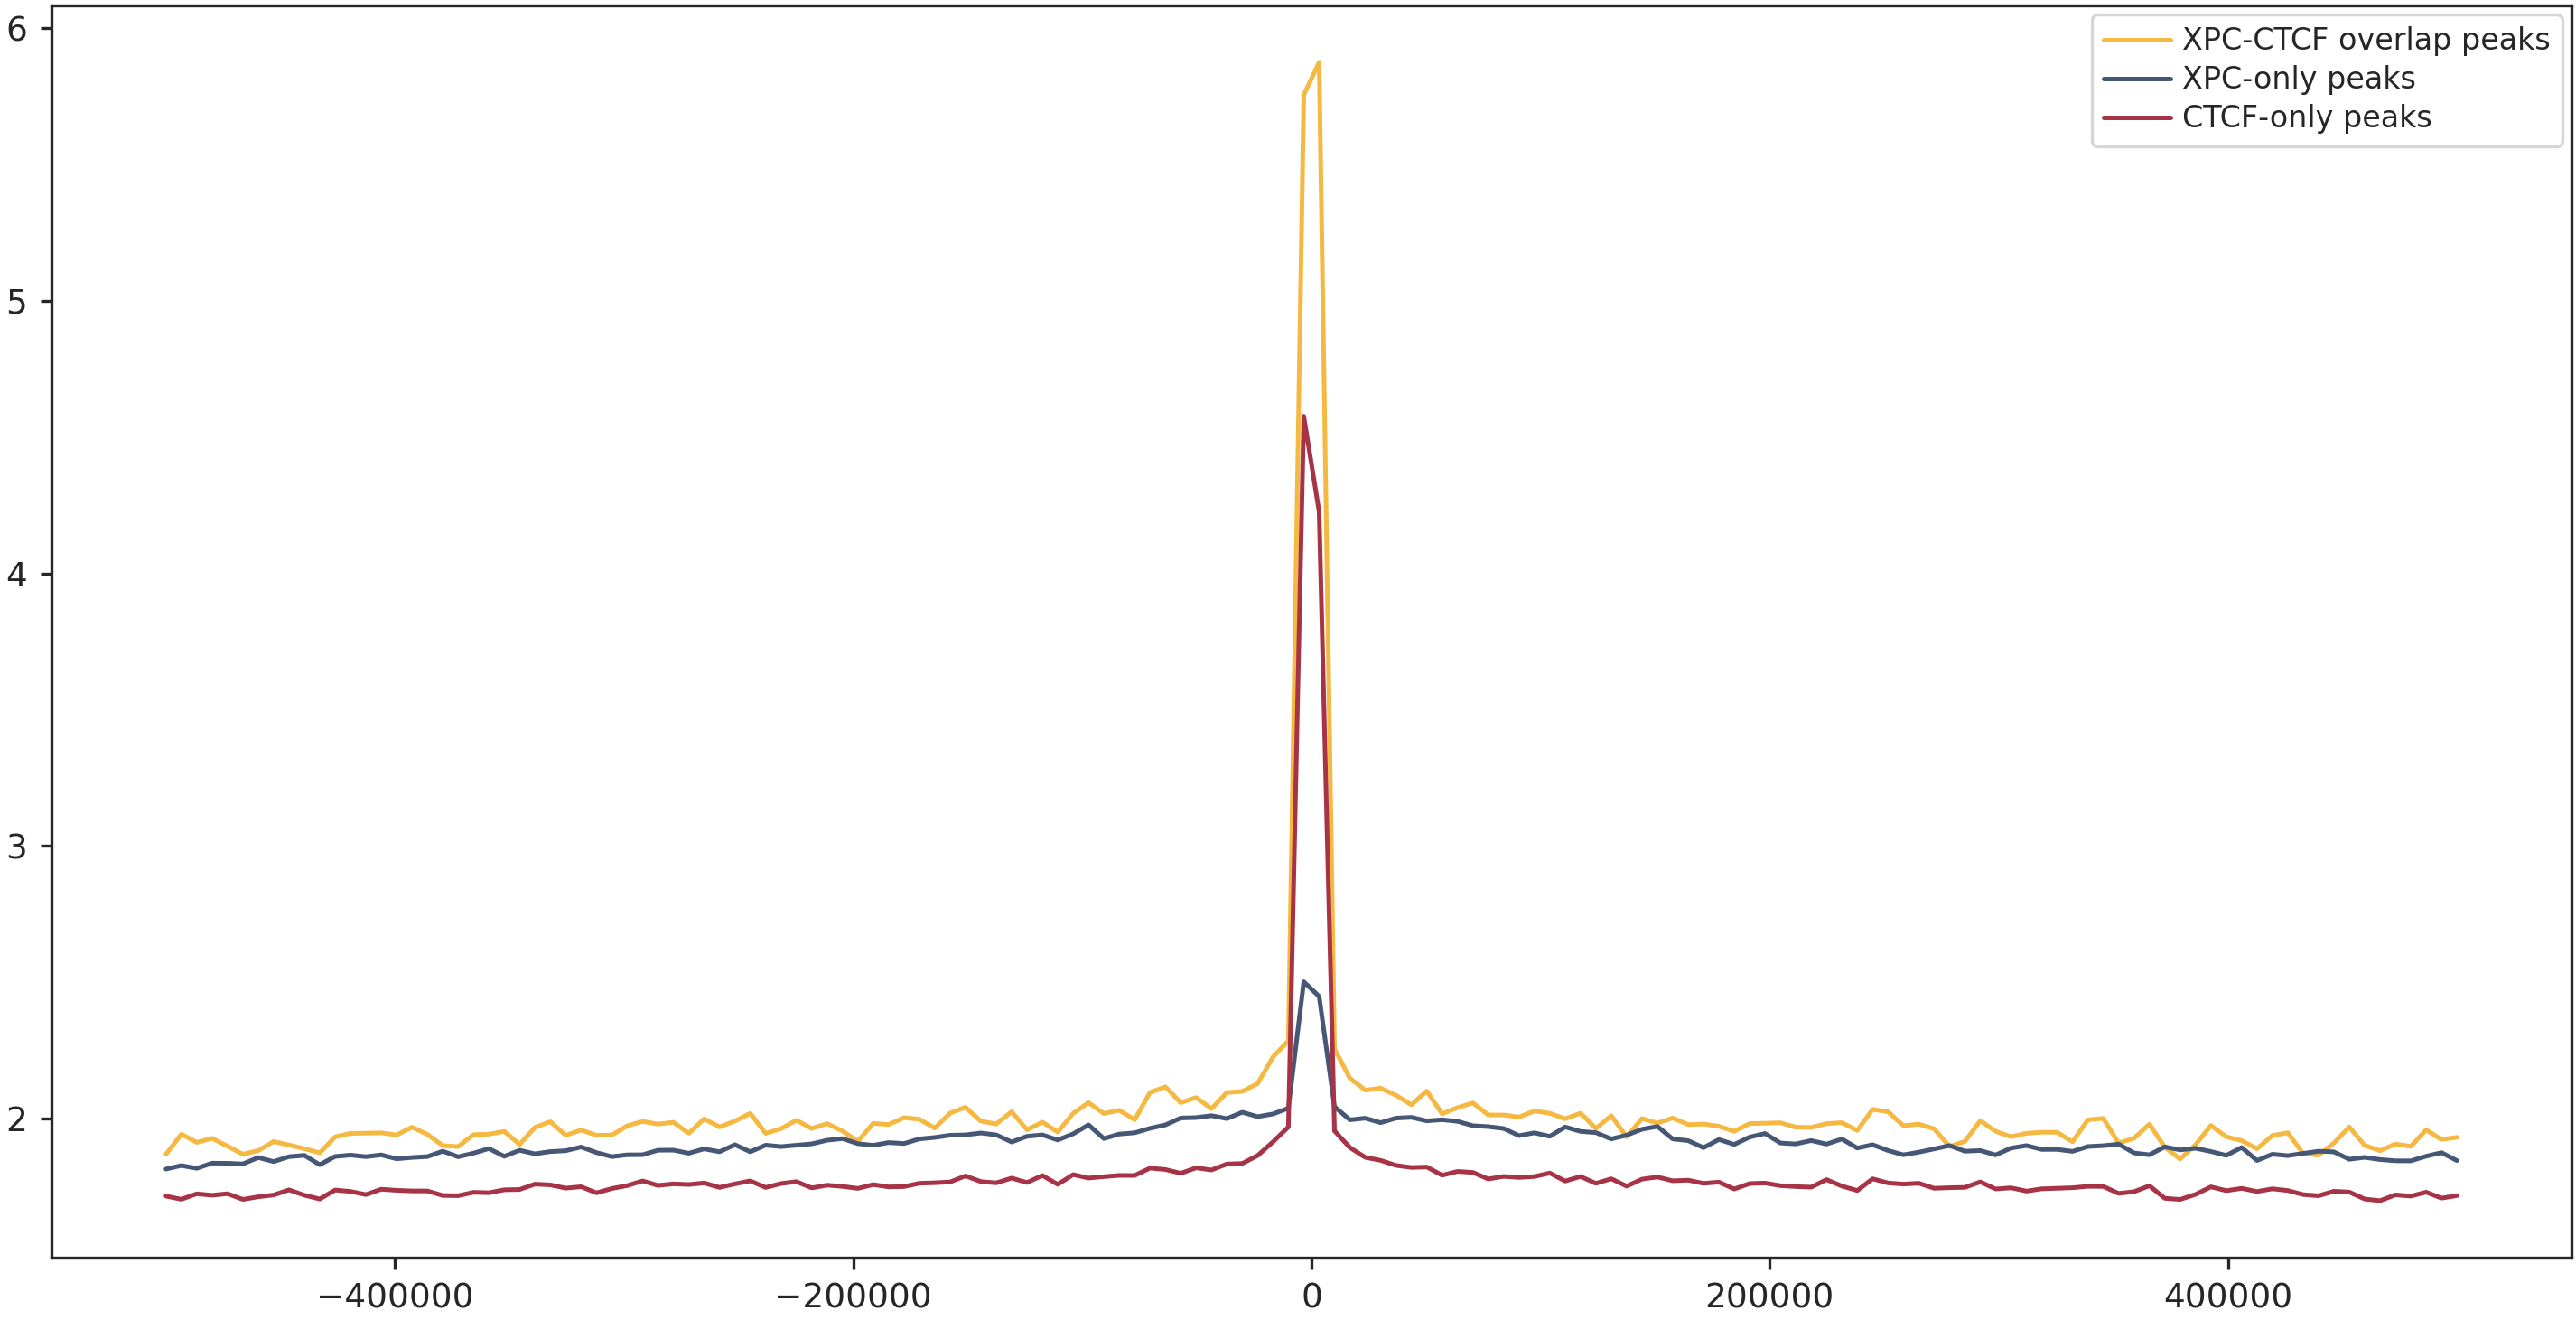

In [13]:
fig, axs = plt.subplots(1, 1, figsize=(12, 6))
colors = plotting.COLORS
sns.lineplot(x=np.linspace(-flank, flank, stackup_overlap_ctcf.shape[1]), y=np.nanmean(stackup_overlap_ctcf, axis=0), color=colors[2], label='XPC-CTCF overlap peaks', ax=axs)
sns.lineplot(x=np.linspace(-flank, flank, stackup_non_overlap_xpc.shape[1]), y=np.nanmean(stackup_non_overlap_xpc, axis=0), color=colors[0], label='XPC-only peaks', ax=axs)
sns.lineplot(x=np.linspace(-flank, flank, stackup_non_overlap_ctcf.shape[1]), y=np.nanmean(stackup_non_overlap_ctcf, axis=0), color=colors[1], label='CTCF-only peaks', ax=axs)

/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:18: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}
/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:18: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}
/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:18: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}


<Axes: >

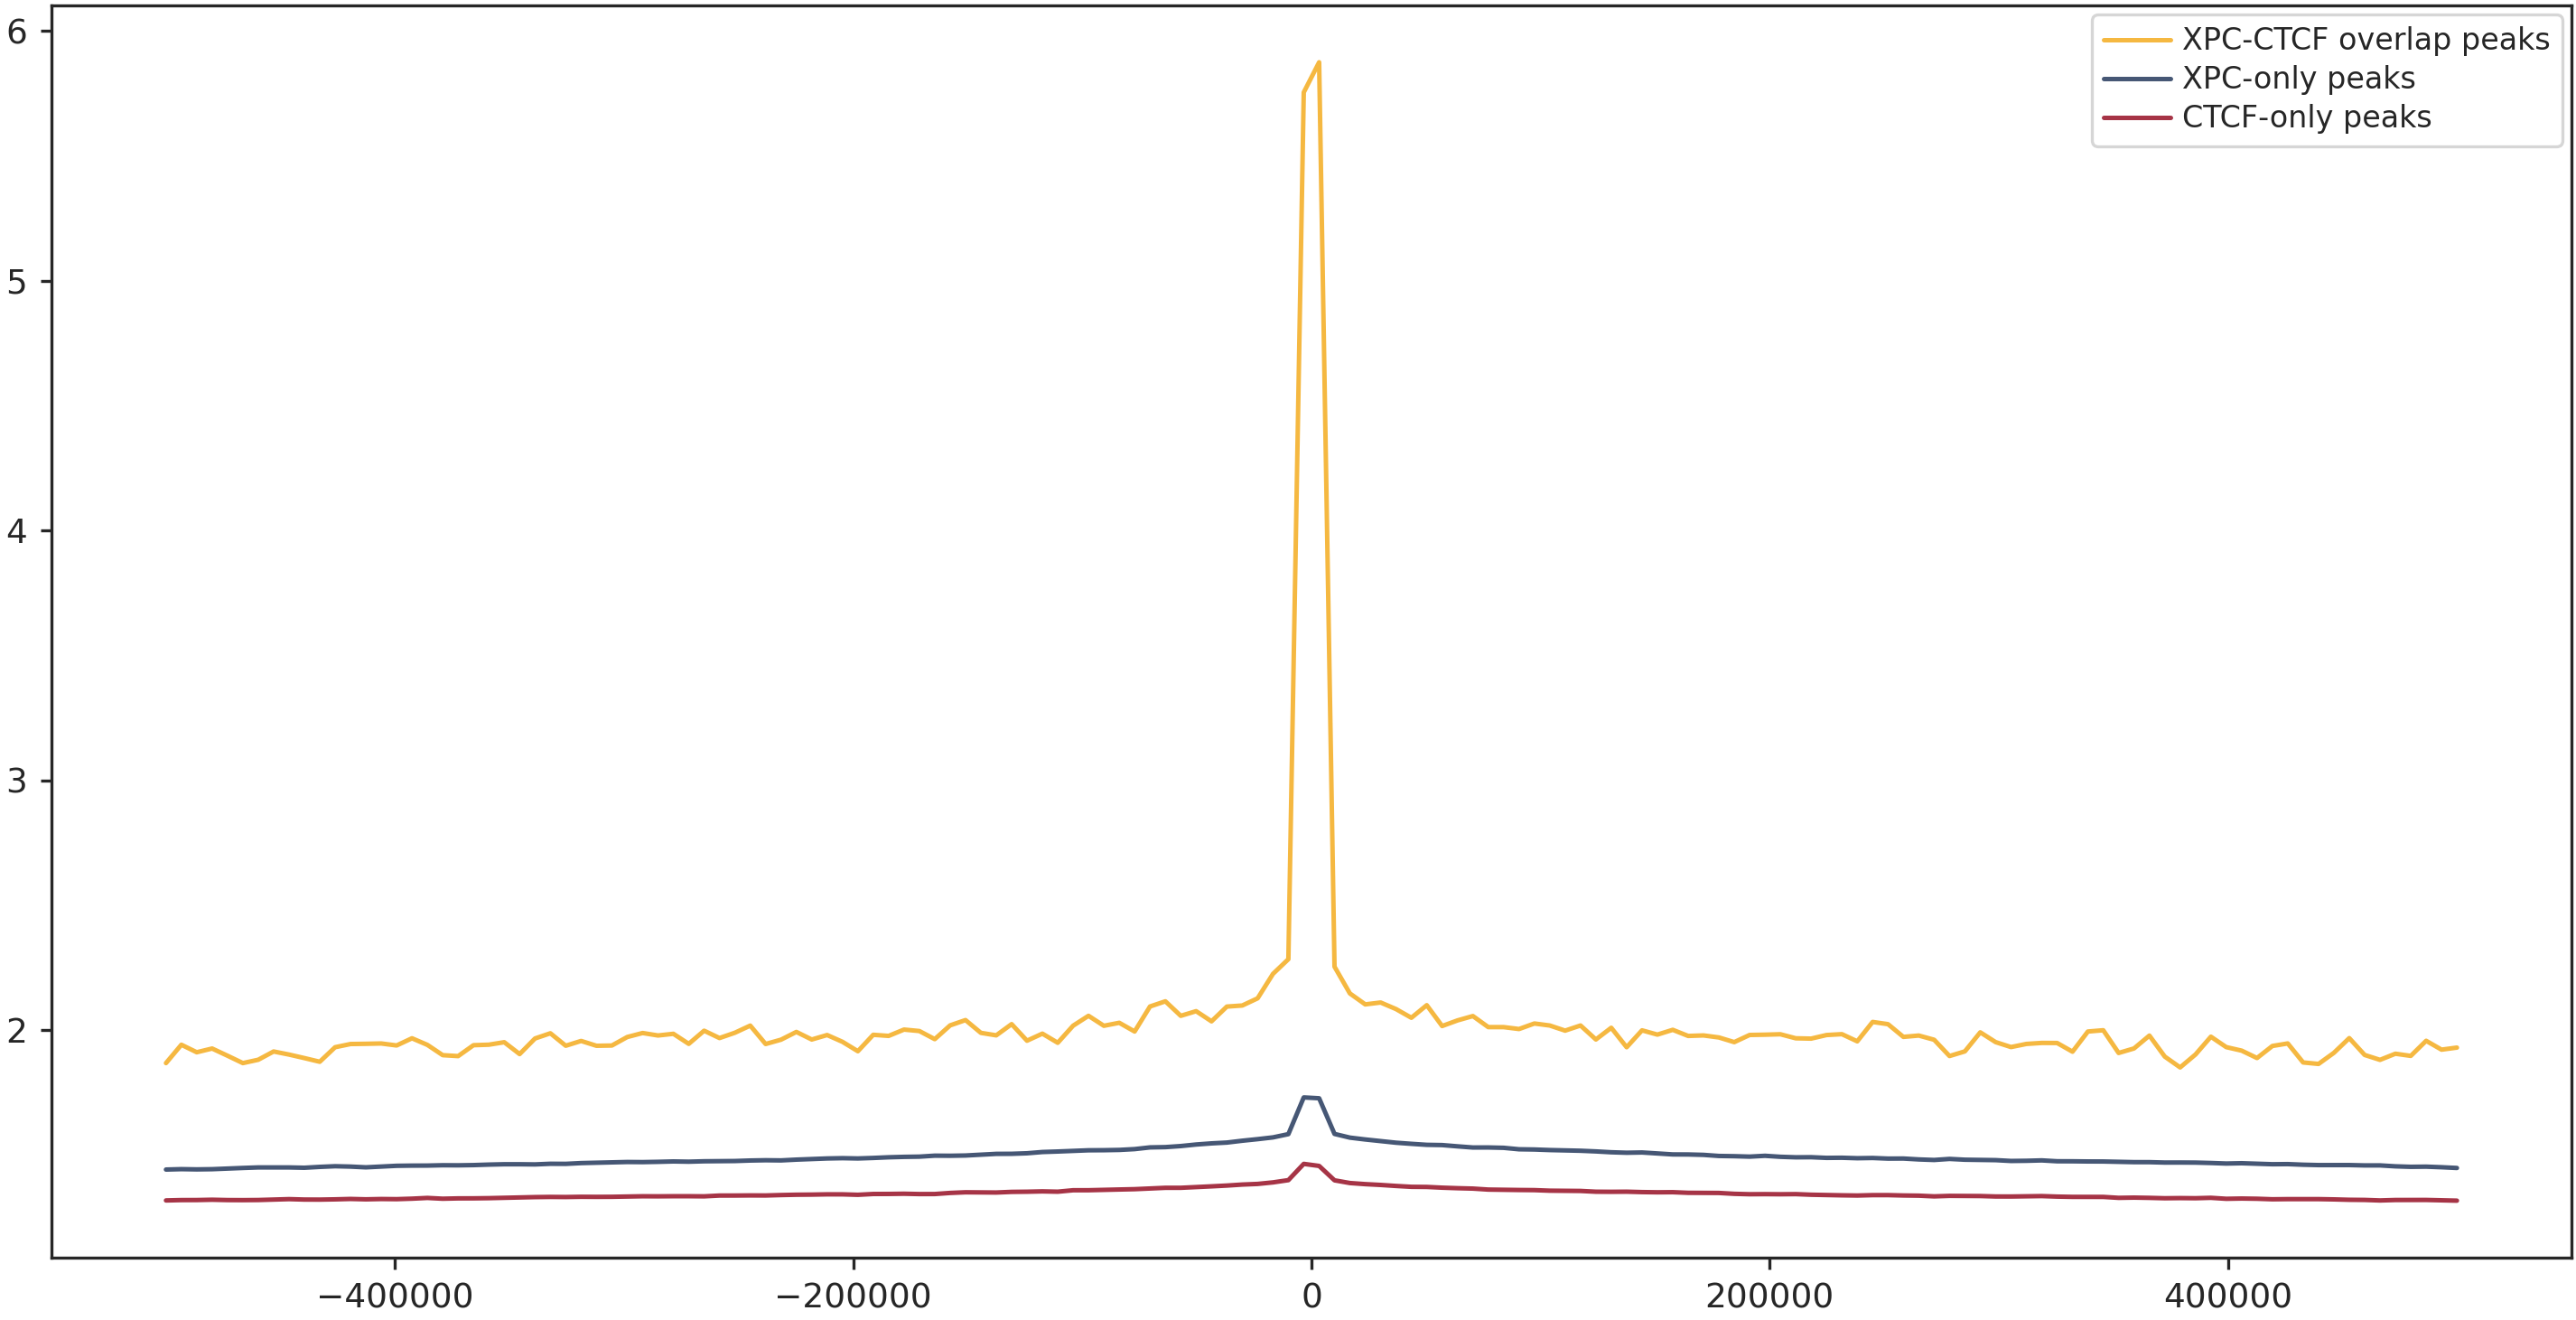

In [18]:
xpc_wtnouv_dict = {
    'wt_nouv_xpc': [
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP2.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP3.mLb.clN.rpgc.bw'
]
}
from ggner_3d.bbi_helpers import stackup_bw_dict

overlap_df = overlap[['chrom_', 'start_', 'end_']].copy()
overlap_df.columns = ['chrom', 'start', 'end']
overlap_df.start = overlap_df.start.astype(int)
overlap_df.end = overlap_df.end.astype(int)
non_overlap_xpc = bf.subtract(xpc_peaks_df, ctcf_peaks_df)
non_overlap_ctcf = bf.subtract(ctcf_peaks_df, xpc_peaks_df)

overlap_df['flank_start'] = overlap_df['start'] + overlap['peak_'] - 1 - flank
overlap_df['flank_end'] = overlap_df['start'] + overlap['peak_'] - 1 + flank
non_overlap_xpc['flank_start'] = non_overlap_xpc['start'] + non_overlap_xpc['peak'] - 1 - flank
non_overlap_xpc['flank_end'] = non_overlap_xpc['start'] + non_overlap_xpc['peak'] - 1 + flank
non_overlap_ctcf['flank_start'] = non_overlap_ctcf['start'] + non_overlap_ctcf['peak'] - 1 - flank
non_overlap_ctcf['flank_end'] = non_overlap_ctcf['start'] + non_overlap_ctcf['peak'] - 1 + flank

overlap_df = filterfor_canonical_chromosomes(overlap_df)
non_overlap_xpc = filterfor_canonical_chromosomes(non_overlap_xpc)
non_overlap_ctcf = filterfor_canonical_chromosomes(non_overlap_ctcf)

stackup_overlap_xpc = stackup_bw_dict(xpc_wtnouv_dict, overlap_df[['chrom', 'flank_start', 'flank_end']], nbins=150)['wt_nouv_xpc']
stackup_non_overlap_xpc = stackup_bw_dict(xpc_wtnouv_dict, non_overlap_xpc[['chrom', 'flank_start', 'flank_end']], nbins=150)['wt_nouv_xpc']
stackup_non_overlap_ctcf = stackup_bw_dict(xpc_wtnouv_dict, non_overlap_ctcf[['chrom', 'flank_start', 'flank_end']], nbins=150)['wt_nouv_xpc']

fig, axs = plt.subplots(1, 1, figsize=(12, 6))
colors = plotting.COLORS
sns.lineplot(x=np.linspace(-flank, flank, stackup_overlap_ctcf.shape[1]), y=np.nanmean(stackup_overlap_ctcf, axis=0), color=colors[2], label='XPC-CTCF overlap peaks', ax=axs)
sns.lineplot(x=np.linspace(-flank, flank, stackup_non_overlap_xpc.shape[1]), y=np.nanmean(stackup_non_overlap_xpc, axis=0), color=colors[0], label='XPC-only peaks', ax=axs)
sns.lineplot(x=np.linspace(-flank, flank, stackup_non_overlap_ctcf.shape[1]), y=np.nanmean(stackup_non_overlap_ctcf, axis=0), color=colors[1], label='CTCF-only peaks', ax=axs)